In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

print(os.getcwd())

C:\Users\Acer\OneDrive\Desktop


In [5]:
import os

print(os.getcwd())

C:\Users\Acer\OneDrive\Desktop


In [8]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

In [10]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [11]:
print("Transaction Class Count:")
print(df["Class"].value_counts())

Transaction Class Count:
Class
0    284315
1       492
Name: count, dtype: int64


In [12]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print("Transaction Percentage:")
print(class_percentage)

Transaction Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


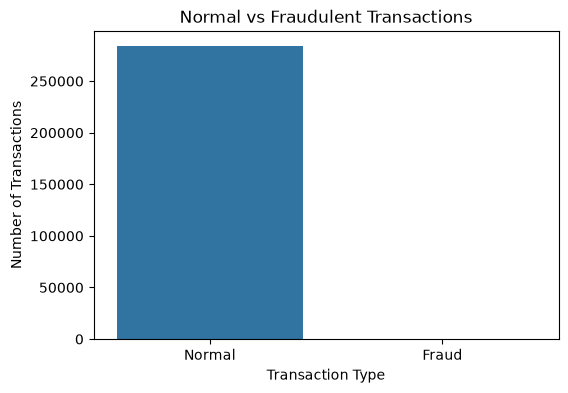

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.xticks([0, 1], ["Normal", "Fraud"])
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title("Normal vs Fraudulent Transactions")

plt.show()

In [14]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (284807, 30)
Output Shape: (284807,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (227845, 30)
Testing Data: (56962, 30)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

print("Model Training Completed!")

Model Training Completed!


In [18]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy * 100, "%")
print("Precision:", precision * 100, "%")
print("Recall   :", recall * 100, "%")
print("F1-Score :", f1 * 100, "%")

Accuracy : 97.55275446789088 %
Precision: 6.097560975609756 %
Recall   : 91.83673469387756 %
F1-Score : 11.435832274459974 %


In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal Transaction", "Fraudulent Transaction"]
))

                        precision    recall  f1-score   support

    Normal Transaction       1.00      0.98      0.99     56864
Fraudulent Transaction       0.06      0.92      0.11        98

              accuracy                           0.98     56962
             macro avg       0.53      0.95      0.55     56962
          weighted avg       1.00      0.98      0.99     56962



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[55478  1386]
 [    8    90]]


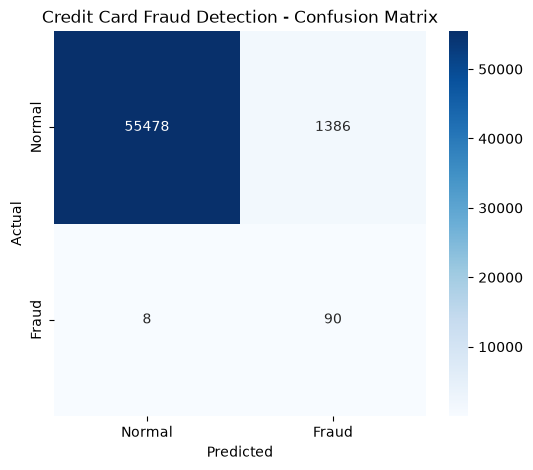

In [22]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Credit Card Fraud Detection - Confusion Matrix")

plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal Transaction", "Fraudulent Transaction"]
))

                        precision    recall  f1-score   support

    Normal Transaction       1.00      0.98      0.99     56864
Fraudulent Transaction       0.06      0.92      0.11        98

              accuracy                           0.98     56962
             macro avg       0.53      0.95      0.55     56962
          weighted avg       1.00      0.98      0.99     56962



In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[55478  1386]
 [    8    90]]


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Training Completed!")

Random Forest Model Training Completed!


In [32]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred[:20])

Random Forest Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [33]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy * 100, "%")
print("Precision:", rf_precision * 100, "%")
print("Recall   :", rf_recall * 100, "%")
print("F1-Score :", rf_f1 * 100, "%")

Random Forest Results
---------------------
Accuracy : 99.94908886626172 %
Precision: 90.58823529411765 %
Recall   : 78.57142857142857 %
F1-Score : 84.15300546448088 %


In [34]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("------------------------------------")

print(classification_report(
    y_test,
    rf_pred,
    target_names=["Normal Transaction", "Fraudulent Transaction"]
))

Random Forest Classification Report
------------------------------------
                        precision    recall  f1-score   support

    Normal Transaction       1.00      1.00      1.00     56864
Fraudulent Transaction       0.91      0.79      0.84        98

              accuracy                           1.00     56962
             macro avg       0.95      0.89      0.92     56962
          weighted avg       1.00      1.00      1.00     56962



In [35]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[56856     8]
 [   21    77]]


In [37]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred) * 100,
        accuracy_score(y_test, rf_pred) * 100
    ],
    "Precision": [
        precision_score(y_test, y_pred) * 100,
        precision_score(y_test, rf_pred) * 100
    ],
    "Recall": [
        recall_score(y_test, y_pred) * 100,
        recall_score(y_test, rf_pred) * 100
    ],
    "F1-Score": [
        f1_score(y_test, y_pred) * 100,
        f1_score(y_test, rf_pred) * 100
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,97.552754,6.097561,91.836735,11.435832
1,Random Forest,99.949089,90.588235,78.571429,84.153005


In [38]:
import joblib

joblib.dump(rf_model, "fraud_detection_model.pkl")

print("Fraud Detection Model Saved Successfully!")

Fraud Detection Model Saved Successfully!
